In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/test.csv
/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv


In [2]:
data = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Data fields

Here's a brief version of what you'll find in the data description file.

1. SalePrice (**цена продажи недвижимости**) - the property's sale price in dollars. This is the target variable that you're trying to predict. 
2. MSSubClass (**Класс здания**): The building class
3. MSZoning (**Общая классификация зонирования**): The general zoning classification
4. LotFrontage (**размер(ширина) фасада(от дома до дороги)**): Linear feet of street connected to property
5. LotArea (**площадь дома**): Lot size in square feet
6. Street (**Тип подъездной дороги**): Type of road access
7. Alley (**Тип подъезда к аллее**): Type of alley access
8. LotShape (**Общий вид собственности**): General shape of property
9. LandContour (**контур земли**): Flatness of the property
10. Utilities (**Тип доступных коммуникаций**): Type of utilities available
11. LotConfig (**Конфигурация**): Lot configuration
12. LandSlope (**Наклон собственности**): Slope of property
13. Neighborhood (**Физические места в черте города Эймс**): Physical locations within Ames city limits
14. Condition1 (**Близость к главной дороге или железной дороге**): Proximity to main road or railroad
15. Condition2 (**Близость к главной дороге или железной дороге (если есть второй)**): Proximity to main road or railroad (if a second is present)
16. BldgType (**Тип жилья**): Type of dwelling
17. HouseStyle (**Стиль жилища**): Style of dwelling
18. OverallQual (**Общее качество материала и отделки**): Overall material and finish quality
19. OverallCond (**Общий рейтинг состояния**): Overall condition rating
20. YearBuilt (**Дата первоначального строительства**): Original construction date
21. YearRemodAdd (**Дата реконструкции**): Remodel date
22. RoofStyle (**Тип крыши**): Type of roof
23. RoofMatl (**Материал крыши**): Roof material
24. Exterior1st (**Наружное покрытие дома**): Exterior covering on house
25. Exterior2nd (**Наружное покрытие дома (если больше одного материала)**): Exterior covering on house (if more than one material)
26. MasVnrType (**Тип облицовки кладки**): Masonry veneer type
27. MasVnrArea (**Площадь облицовки каменной кладкой в квадратных футах**): Masonry veneer area in square feet
28. ExterQual (**Качество наружных материалов**): Exterior material quality
29. ExterCond (**Текущее состояние материала снаружи**): Present condition of the material on the exterior
30. Foundation (**Тип фундамента**): Type of foundation
31. BsmtQual (**Высота подвала**): Height of the basement
32. BsmtCond (**Общее состояние подвала**): General condition of the basement
33. BsmtExposure (**Стены подвала на уровне сада или выхода**): Walkout or garden level basement walls
34. BsmtFinType1 (**Качество готовой площади подвала**): Quality of basement finished area
35. BsmtFinSF1 (**Готовая площадь типа 1**): Type 1 finished square feet
36. BsmtFinType2 (**Качество второй готовой площади (при наличии)**): Quality of second finished area (if present)
37. BsmtFinSF2 (**Готовая площадь типа 2**): Type 2 finished square feet
38. BsmtUnfSF (**Незаконченные квадратные метры подвала**): Unfinished square feet of basement area
39. TotalBsmtSF (**Общая площадь подвала в квадратных футах**): Total square feet of basement area
40. Heating (**Тип отопления**): Type of heating
41. HeatingQC (**Качество и состояние отопления**): Heating quality and condition
42. CentralAir (**Центральное кондиционирование**): Central air conditioning
43. Electrical (**Электрическая система**): Electrical system
44. 1stFlrSF (**Площадь первого этажа**): First Floor square feet
45. 2ndFlrSF (**Площадь второго этажа**): Second floor square feet
46. LowQualFinSF (**Некачественная отделка квадратных футов (все этажи)**): Low quality finished square feet (all floors)
47. GrLivArea (**Надземная жилая площадь квадратных футов**): Above grade (ground) living area square feet
48. BsmtFullBath (**Полные ванные комнаты в подвале**): Basement full bathrooms
49. BsmtHalfBath (**Цокольные полуванные комнаты**): Basement half bathrooms
50. FullBath (**Полные ванные комнаты выше уровня**): Full bathrooms above grade
51. HalfBath (**Полуванны над уровнем моря**): Half baths above grade
52. BedroomAbvGr (**Количество спален над цокольным этажом**): Number of bedrooms above basement level
53. KitchenAbvGr (**Кол-во кухонь**): Number of kitchens
54. KitchenQual (**Качество кухни**): Kitchen quality
55. TotRmsAbvGrd (**Всего комнат выше уровня (без ванных комнат)**): Total rooms above grade (does not include bathrooms)
56. Functional (**Рейтинг функциональности дома**): Home functionality rating
57. Fireplaces (**Количество каминов**): Number of fireplaces
58. FireplaceQu (**Качество камина**): Fireplace quality
59. GarageType (**Расположение гаража**): Garage location
60. GarageYrBlt (**Год постройки гаража**): Year garage was built
61. GarageFinish (**Внутренняя отделка гаража**): Interior finish of the garage
62. GarageCars (**Размер гаража в вместимости машины**): Size of garage in car capacity
63. GarageArea (**Размер гаража в квадратных футах**): Size of garage in square feet
64. GarageQual (**Качество гаража**): Garage quality
65. GarageCond (**Состояние гаража**): Garage condition
66. PavedDrive (**Асфальтированная дорога**): Paved driveway
67. WoodDeckSF (**Площадь деревянной террасы в квадратных футах**): Wood deck area in square feet
68. OpenPorchSF (**Площадь открытой веранды в квадратных футах**): Open porch area in square feet
69. EnclosedPorch (**Площадь закрытого крыльца в квадратных футах**): Enclosed porch area in square feet
70. 3SsnPorch (**Площадь крыльца на три сезона в квадратных футах**): Three season porch area in square feet
71. ScreenPorch (**Площадь крыльца экрана в квадратных футах**): Screen porch area in square feet
72. PoolArea (**Площадь бассейна в квадратных футах**): Pool area in square feet
73. PoolQC (**Качество бассейна**): Pool quality
74. Fence (**Качество забора**): Fence quality
75. MiscFeature (**Прочие функции, не включенные в другие категории**): Miscellaneous feature not covered in other categories
76. MiscVal (**Ценность дополнительных функций**): Value of miscellaneous feature
77. MoSold (**Месяц продажи**): Month Sold
78. YrSold (**количество лет**): Year Sold
79. SaleType (**Тип продажи**): Type of sale
80. SaleCondition (**Состояние продажи**): Condition of sale

http://web.stanford.edu/class/stats191/data/amesdoc.txt

# Create train data

In [3]:
y_train = data.SalePrice

In [4]:
X_train = pd.DataFrame()

In [5]:
print(data.columns.size)

81


In [6]:
columns = list(data.columns)

If not have LotFrontage, then LotFrontage = 0 (not frontage)

In [7]:
numerical_data = ["MSSubClass", "LotFrontage", "LotArea", "OverallQual", "OverallCond", 
                  "MasVnrArea", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", 
                  "LowQualFinSF", "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "FullBath", 
                  "HalfBath", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",  "GarageCars", 
                  "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", 
                  "ScreenPorch", "PoolArea", "MiscVal", "BsmtFinSF1", "BsmtFinSF2", 
                  "BedroomAbvGr"]
for col in numerical_data:
    print(col, data[col].isnull().sum())
    X_train[col] = data[col]

MSSubClass 0
LotFrontage 259
LotArea 0
OverallQual 0
OverallCond 0
MasVnrArea 8
BsmtUnfSF 0
TotalBsmtSF 0
1stFlrSF 0
2ndFlrSF 0
LowQualFinSF 0
GrLivArea 0
BsmtFullBath 0
BsmtHalfBath 0
FullBath 0
HalfBath 0
KitchenAbvGr 0
TotRmsAbvGrd 0
Fireplaces 0
GarageCars 0
GarageArea 0
WoodDeckSF 0
OpenPorchSF 0
EnclosedPorch 0
3SsnPorch 0
ScreenPorch 0
PoolArea 0
MiscVal 0
BsmtFinSF1 0
BsmtFinSF2 0
BedroomAbvGr 0


In [8]:
X_train.LotFrontage = X_train.LotFrontage.fillna(0)
X_train.LotFrontage.isnull().sum()

0

In [9]:
X_train.MasVnrArea = X_train.MasVnrArea.fillna(0)
X_train.MasVnrArea.isnull().sum()

0

## Other columns: categorical and date

In [10]:
other_columns = []
for col in columns:
    if numerical_data.count(col) < 1:
        other_columns.append(col)
print(other_columns)

['Id', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'SalePrice']


# date data

In [11]:
import math

In [12]:
def Sturges_interval(data, column):
    
    x_max = data[column].max()
    x_min = data[column].min()
    
    n = data[column].size # count elements

    m = 1 + math.log(n, 2) # count intervals
    h = math.ceil((x_max - x_min) / m) # Sturges's formula 
    x_start = round(x_min - h / 2)
    
    intervals = []
    for i in range(round(m)):
        
        interval = [x_start, x_start + h]
        intervals.append(interval)
        x_start = interval[1]
    
    return intervals 

In [13]:
def col_new(data, column, intervals):
    m = 0
    for inter in intervals:
        m = m + 1
    i = 0
    for interval in intervals:
        i = i + 1
        value = []
        if i == m:
            for value_col in data[column]:
                if value_col <= int(interval[1]) and value_col >= int(interval[0]):
                    val = 1
                else:
                    val = 0
                value.append(val)
        else:
            for value_col in data[column]:
                if value_col < int(interval[1]) and value_col >= int(interval[0]):
                    val = 1
                else:
                    val = 0
                value.append(val)
    
        X_train["["+str(interval[0])+" ,"+str(interval[1]) + ")"] = value

In [14]:
X_test = pd.read_csv("../input/house-prices-advanced-regression-techniques/test.csv")

In [15]:
date_data = ["YearBuilt", "YearRemodAdd", "GarageYrBlt"]

for col in date_data:
    print(col, " train :", data[col].min(), data[col].max())
    print(col, " test :", X_test[col].min(), X_test[col].max())

YearBuilt  train : 1872 2010
YearBuilt  test : 1879 2010
YearRemodAdd  train : 1950 2010
YearRemodAdd  test : 1950 2010
GarageYrBlt  train : 1900.0 2010.0
GarageYrBlt  test : 1895.0 2207.0


Test data contains incorrect data (example: GarageYrBlt.max() = 2207 year), so I won't check on test data
😕

In [16]:
X_train.shape

(1460, 31)

In [17]:
date_data = ["YearBuilt", "YearRemodAdd", "GarageYrBlt"]

for col in date_data:
    intervals = Sturges_interval(data, col)
    print(col, intervals)
    col_new(data, col, intervals)

X_train = X_train.drop("[2013 ,2019)", axis=1)

YearBuilt [[1866, 1878], [1878, 1890], [1890, 1902], [1902, 1914], [1914, 1926], [1926, 1938], [1938, 1950], [1950, 1962], [1962, 1974], [1974, 1986], [1986, 1998], [1998, 2010]]
YearRemodAdd [[1947, 1953], [1953, 1959], [1959, 1965], [1965, 1971], [1971, 1977], [1977, 1983], [1983, 1989], [1989, 1995], [1995, 2001], [2001, 2007], [2007, 2013], [2013, 2019]]
GarageYrBlt [[1895, 1905], [1905, 1915], [1915, 1925], [1925, 1935], [1935, 1945], [1945, 1955], [1955, 1965], [1965, 1975], [1975, 1985], [1985, 1995], [1995, 2005], [2005, 2015]]


In [18]:
X_train.shape

(1460, 66)

In [19]:
Month = [i + 1 for i in range(12)] 
Month

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [20]:
# date data Sold: "MoSold", "YrSold"

months = [i + 1 for i in range(12)] 

for month in months:
    X_train["month_" + str(month)] = [int(val == month) for val in data.MoSold]

In [21]:
X_train.shape

(1460, 78)

In [22]:
YrSold = list(data.YrSold.unique())

for year in YrSold:
    X_train["year_sold_" + str(year)] = [int(val == year) for val in data.YrSold]

In [23]:
X_train.shape

(1460, 83)

In [24]:
date_data = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold", "MoSold"]

# Categorical columns

In [25]:
cotegorical_columns = []
for col in other_columns:
    if date_data.count(col) < 1:
        cotegorical_columns.append(col)
print(cotegorical_columns)

['Id', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition', 'SalePrice']


# Columns DROP

In [26]:
for col in cotegorical_columns:
    print(col, " nan % = ", 100 * (data[col].size - data[col].value_counts().sum()) / data[col].size)

Id  nan % =  0.0
MSZoning  nan % =  0.0
Street  nan % =  0.0
Alley  nan % =  93.76712328767124
LotShape  nan % =  0.0
LandContour  nan % =  0.0
Utilities  nan % =  0.0
LotConfig  nan % =  0.0
LandSlope  nan % =  0.0
Neighborhood  nan % =  0.0
Condition1  nan % =  0.0
Condition2  nan % =  0.0
BldgType  nan % =  0.0
HouseStyle  nan % =  0.0
RoofStyle  nan % =  0.0
RoofMatl  nan % =  0.0
Exterior1st  nan % =  0.0
Exterior2nd  nan % =  0.0
MasVnrType  nan % =  0.547945205479452
ExterQual  nan % =  0.0
ExterCond  nan % =  0.0
Foundation  nan % =  0.0
BsmtQual  nan % =  2.5342465753424657
BsmtCond  nan % =  2.5342465753424657
BsmtExposure  nan % =  2.6027397260273974
BsmtFinType1  nan % =  2.5342465753424657
BsmtFinType2  nan % =  2.6027397260273974
Heating  nan % =  0.0
HeatingQC  nan % =  0.0
CentralAir  nan % =  0.0
Electrical  nan % =  0.0684931506849315
KitchenQual  nan % =  0.0
Functional  nan % =  0.0
FireplaceQu  nan % =  47.26027397260274
GarageType  nan % =  5.5479452054794525
Gara

Columns Drop: 
1. Id - not needed for train
2. SalePrice - y_train
3. too much unknown data:
    * Alley
    * FireplaceQu
    * PoolQC
    * Fence
    * MiscFeature

In [27]:
drop_columns = ["SalePrice", "Id", "Alley", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"]

cotegorical_nim_nan_columns = []
for col in cotegorical_columns:
    if drop_columns.count(col) < 1:
        cotegorical_nim_nan_columns.append(col)
print(cotegorical_nim_nan_columns)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


# Categorical data: shortcut encoding or One-Hot Encoding

data dont have nan

In [28]:
cotegorical_have_nan_columns = []
cotegorical_columns = []
for col in cotegorical_nim_nan_columns:
    percent = 100 * (data[col].size - data[col].value_counts().sum()) / data[col].size
    if percent > 0:
        cotegorical_have_nan_columns.append(col)
    else:
        cotegorical_columns.append(col)
print(cotegorical_columns)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir', 'KitchenQual', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition']


## MSZoning 
(Общая классификация зонирования): The general zoning classification

In [29]:
data.MSZoning.unique()

array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

1. 'RL' - Residential Low Density. The RL district is applied to areas of the city appropriate for low density residential uses in a neighborhood with predominately detached single-family dwellings, but allows a diversity of compatible housing types and lot sizes from larger lot single-family dwellings to cottages, cluster, courtyard, and patio homes, and duplexes, at densities of two and one-half to 10 units per net acre. The RL district is consistent with and implements the low density residential (LDR) land use designation of the general plan.
2. 'RM' - Residential Medium Density. The RM district is applied to areas of the city appropriate for residential uses with attached and detached dwellings, including a variety of housing types such as small lot single-family dwellings, townhomes, row houses, and cluster housing, at densities of 11 to 33 units per net acre, with provisions for appropriately scaled and located live/work units. The RM district is consistent with and implements the medium density residential (MDR) land use designation of the general plan. 
3. 'C (all)', 
4. 'FV' - Floating Village Residential, 
5. 'RH' - Residential High Density. The RH district is applied to areas of the city appropriate for compact, high density, multifamily residential development including apartments, townhomes, and condominiums at densities ranging from 33 to 100 units per net acre, with limited provisions for appropriately scaled and located live/work units. The RH district is consistent with and implements the high density residential (HDR) land use designation of the general plan.

In [30]:
new_msz = {"RL": 4, "RM": 3, "RH": 2, "FV": 1, "C (all)": 0} #categorical variable

X_train["MSZoning"] = [new_msz[val] for val in data.MSZoning]

## Street 
(Тип подъездной дороги): Type of road access

In [31]:
data.Street.unique()

array(['Pave', 'Grvl'], dtype=object)

In [32]:
new_Street = {"Pave": 0, "Grvl": 1} #binary variable

X_train["Street"] = [new_Street[val] for val in data.Street]

## Utilities
(Тип доступных коммуникаций): Type of utilities available

In [33]:
data.Utilities.unique()

array(['AllPub', 'NoSeWa'], dtype=object)

1. AllPub - All public Utilities (E,G,W,& S)	
2. NoSeWa - Electricity and Gas Only

In [34]:
new_Utilities= {"NoSeWa": 0, "AllPub": 1} #binary variable

X_train["Utilities"] = [new_Utilities[val] for val in data.Utilities]

## LandSlope 
(Наклон ланшафта): Slope of property

1. Gtl - Gentle slope
2. Mod - Moderate Slope	
3. Sev - Severe Slope
	

In [35]:
new_LandSlope = {'Gtl': 2, 'Mod' : 1, 'Sev' : 0}

X_train["LandSlope"] = [new_LandSlope[val] for val in data.LandSlope]

## Condition1 and Condition2

1. Artery	Adjacent to arterial street
2. Feedr	Adjacent to feeder street	
3. Norm	Normal	
4. RRNn	Within 200' of North-South Railroad
5. RRAn	Adjacent to North-South Railroad
6. PosN	Near positive off-site feature--park, greenbelt, etc. 
7. PosA	Adjacent to postive off-site feature
8. RRNe	Within 200' of East-West Railroad
9. RRAe	Adjacent to East-West Railroad

In [36]:
Condition = {'Norm': 6, 'Feedr': 1, 'PosN': 8, 'Artery': 0, 'RRAe': 3, 'RRNn': 5, 'RRAn': 2, 'PosA': 7, 'RRNe': 4}

X_train["Condition1"] = [Condition[val] for val in data.Condition1]
X_train["Condition2"] = [Condition[val] for val in data.Condition2]


## BldgType
1. 1Fam	Single-family Detached	
2. 2FmCon	Two-family Conversion; originally built as one-family dwelling
3. Duplx	Duplex
4. TwnhsE	Townhouse End Unit
5. TwnhsI	Townhouse Inside Unit

In [37]:
BldgType = {'1Fam': 4, '2fmCon': 0, 'Duplex': 3, 'TwnhsE': 2, 'Twnhs': 0}

X_train["BldgType"] = [BldgType[val] for val in data.BldgType]

## HouseStyle

1. 1Story	One story
2. 1.5Fin	One and one-half story: 2nd level finished
3. 1.5Unf	One and one-half story: 2nd level unfinished
4. 2Story	Two story
5. 2.5Fin	Two and one-half story: 2nd level finished
6. 2.5Unf	Two and one-half story: 2nd level unfinished
7. SFoyer	Split Foyer
8. SLvl	Split Level

In [38]:
HouseStyle = {'2Story':5, '1Story':0, '1.5Fin':2, '1.5Unf':1, 'SFoyer':4, 'SLvl':3, '2.5Unf': 6,'2.5Fin': 7}

X_train["HouseStyle"] = [HouseStyle[val] for val in data.HouseStyle]


## RoofStyle
![](https://www.cupapizarras.com/wp-content/uploads/2018/09/types_of_roofs.jpg)

In [39]:
RoofStyle = {'Gable':4, 'Hip':3, 'Gambrel':2, 'Mansard':5, 'Flat': 0, 'Shed':1}
X_train["RoofStyle"] = [RoofStyle[val] for val in data.RoofStyle]


## RoofMatl 

[link](https://www.thespruce.com/basic-types-and-cost-of-roofing-materials-1822016)
### price:
1. 'CompShg' - ```$9 to $12```, 50 years 
2. 'WdShngl' - ```$30 to $75```, 75 to 200 years 
3. 'Metal', - ```$6 to $12```, 30 to 50 years
4. 'WdShake' - ```$4.50 to $9```, 20 years
5. 'Membran' - ```$3 to $4```, 20 to 35 years 
6. 'Tar&Grv', - ```$2.50 to $5```, 20 to 30 years
7. 'Roll' - ```$1.50 to $2.50```; 10 years
8. 'ClyTile' - ```$10 to $18```, very long (100) 

In [40]:
roof = pd.DataFrame()
roof["material"] = ['CompShg', 'WdShngl', 'Metal', 'WdShake', 'Membran', 'Tar&Grv', 'Roll', 'ClyTile']
roof["min_price"] = [9, 30, 6, 4.50, 3, 2.50, 1.50, 10]
roof["max_price"] = [12, 75, 12, 9, 4, 5, 2.50, 18]
roof["year"] = [50, 75, 30, 20, 20, 20, 10, 100]
roof["$_year"] = ((roof.max_price + roof.min_price) / 2) /roof.year
roof.sort_values(by=["$_year", "year"])

,material,min_price,max_price,year,$_year
7,ClyTile,10.0,18.0,100,0.1400
4,Membran,3.0,4.0,20,0.1750
5,Tar&Grv,2.5,5.0,20,0.1875
6,Roll,1.5,2.5,10,0.2000
0,CompShg,9.0,12.0,50,0.2100
2,Metal,6.0,12.0,30,0.3000
3,WdShake,4.5,9.0,20,0.3375
1,WdShngl,30.0,75.0,75,0.7000


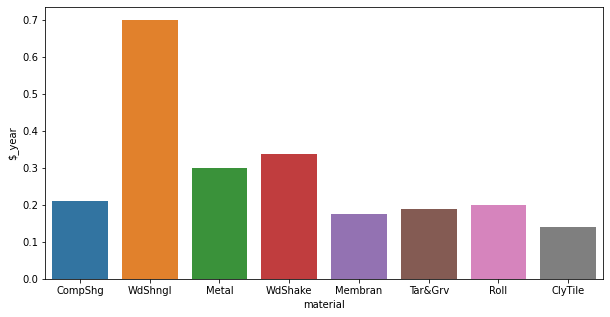

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.barplot(x="material" , y="$_year", data=roof)

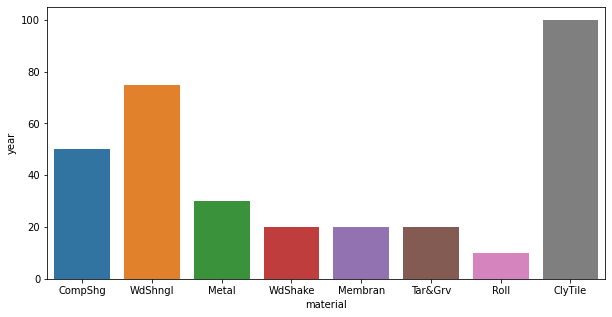

In [42]:
plt.figure(figsize=(10,5))
sns.barplot(x="material" , y="year", data=roof)

In [43]:
roof.sort_values(by=["$_year", "year"])

,material,min_price,max_price,year,$_year
7,ClyTile,10.0,18.0,100,0.1400
4,Membran,3.0,4.0,20,0.1750
5,Tar&Grv,2.5,5.0,20,0.1875
6,Roll,1.5,2.5,10,0.2000
0,CompShg,9.0,12.0,50,0.2100
2,Metal,6.0,12.0,30,0.3000
3,WdShake,4.5,9.0,20,0.3375
1,WdShngl,30.0,75.0,75,0.7000


In [44]:
RoofMatl = {'CompShg': 4, 'WdShngl': 0, 'Metal': 2, 'WdShake':1, 'Membran': 6, 'Tar&Grv': 5, 'Roll': 3, 'ClyTile': 7}

X_train["RoofMatl"] = [RoofMatl[val] for val in data.RoofMatl]


## Foundation

In [45]:
Foundation = {'PConc':5, 'CBlock':2, 'BrkTil':1, 'Wood':0, 'Slab':4, 'Stone':3}

X_train["Foundation"] = [Foundation[val] for val in data.Foundation]


## Heating

In [46]:
Heating = {'GasA':4, 'GasW':5, 'Grav':3, 'Wall':0, 'OthW':2, 'Floor':1}
X_train["Heating"] = [Heating[val] for val in data.Heating]


## HeatingQC and KitchenQual

In [47]:
meaning = {'Ex': 4, 'Gd':3, 'TA':2, 'Fa':1, 'Po':0}
X_train["HeatingQC"] = [meaning[val] for val in data.HeatingQC]
X_train["KitchenQual"] = [meaning[val] for val in data.KitchenQual]


## CentralAir

In [48]:
CentralAir = {'Y':1, 'N':0}
X_train["CentralAir"] = [CentralAir[val] for val in data.CentralAir]


## PavedDrive

In [49]:
PavedDrive = {'Y':2, 'N':0, 'P':1}
X_train["PavedDrive"] = [PavedDrive[val] for val in data.PavedDrive]


# cotegorical_have_nan_columns

In [50]:
cotegorical_have_nan_columns

['MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond']

In [51]:
meaning = {'Ex': 5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, "Na":0}

X_train["BsmtQual"] = data.BsmtQual.fillna("Na")
X_train["BsmtQual"] = [meaning[val] for val in X_train.BsmtQual]

X_train["BsmtCond"] = data.BsmtCond.fillna("Na")
X_train["BsmtCond"] = [meaning[val] for val in X_train.BsmtCond]

X_train["GarageQual"] = data.GarageQual.fillna("Na")
X_train["GarageQual"] = [meaning[val] for val in X_train.GarageQual]

X_train["GarageCond"] = data.GarageCond.fillna("Na")
X_train["GarageCond"] = [meaning[val] for val in X_train.GarageCond]

In [52]:
meaning = {'No':1, 'Gd':4, 'Mn':2, 'Av':3, "Na":0}

X_train["BsmtExposure"] = data.BsmtExposure.fillna("Na")
X_train["BsmtExposure"] = [meaning[val] for val in X_train.BsmtExposure]

In [53]:
meaning = {'GLQ':6, 'ALQ':5, 'Unf':1, 'Rec':3, 'BLQ':4, "Na":0, 'LwQ':2}

X_train["BsmtFinType1"] = data.BsmtFinType1.fillna("Na")
X_train["BsmtFinType1"] = [meaning[val] for val in X_train.BsmtFinType1]

X_train["BsmtFinType2"] = data.BsmtFinType2.fillna("Na")
X_train["BsmtFinType2"] = [meaning[val] for val in X_train.BsmtFinType2]

In [54]:
X_train["MasVnrType"] = data.MasVnrType.fillna("None")
X_train["Electrical"] = data.Electrical.fillna("Mix")
X_train["GarageType"] = data.GarageType.fillna("Na")

one_hot_columns = ["MasVnrType", "Electrical", "GarageType"]
for col in one_hot_columns:
    uniques = list(X_train[col].unique())
    for unique in uniques:
        X_train[col + '_' + str(unique)] = [int(val == unique) for val in X_train[col]]
    X_train = X_train.drop(col, axis=1)

In [55]:
meaning = {'RFn':2, 'Unf':1, 'Fin':3, "Na":0}

X_train["GarageFinish"] = data.GarageFinish.fillna("Na")
X_train["GarageFinish"] = [meaning[val] for val in X_train.GarageFinish]

## one_hot_columns

In [56]:
one_hot_columns = ["LotShape", "LandContour", "LotConfig", "Neighborhood", 'Exterior1st', 
                   'Exterior2nd', "Functional", "SaleType", "SaleCondition"]

for col in one_hot_columns:
    uniques = list(data[col].unique())
    for unique in uniques:
        X_train[col + '_' + str(unique)] = [int(val == unique) for val in data[col]]

# standardization

In [57]:
def X_standardization(data, col):
    mean = data[col].mean()
    std = data[col].std()
    data[col] -= mean
    data[col] /= std

def y_standardization(y):
    mean = y.mean()
    std = y.std()
    y -= mean
    y /= std

# z-normalization

In [58]:
def z_normalization_X(data, col):
    N = data[col].size
    x_mean = data[col].mean()
    s_x = 1 / N * sum(abs(data[col]-x_mean))
    data[col] = (data[col] - x_mean) / s_x

def z_normalization_y(y):
    N = y.size
    y_mean = y.mean()
    s_y = 1 / N * sum(abs(y-y_mean))
    y = (y - y_mean) / s_y

# normalization minmax

In [59]:
def normalization_X(data, col):
    x_min = data[col].min()
    x_max = data[col].max()
    data[col] = (data[col] - x_min) / (x_max - x_min)

def normalization_y(y):
    y_min = y.min()
    y_max = y.max()
    y = (y - y_min) / (y_max - y_min)

In [60]:
X_train_stand = X_train
y_train_stand = y_train

X_train_z_norm = X_train
y_train_z_norm = y_train

X_train_norm = X_train
y_train_norm = y_train

for col in list(X_train.columns):
    X_standardization(X_train_stand, col)
    z_normalization_X(X_train_z_norm, col)
    normalization_X(X_train_norm, col)

y_standardization(y_train_stand)
z_normalization_y(y_train_z_norm)
normalization_y(y_train_norm)

In [61]:
X_train.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,...,SaleType_CWD,SaleType_ConLw,SaleType_Con,SaleType_Oth,SaleCondition_Normal,SaleCondition_Abnorml,SaleCondition_Partial,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family
0,0.235294,0.207668,0.033420,0.666667,0.500,0.12250,0.064212,0.140098,0.119780,0.413559,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.255591,0.038795,0.555556,0.875,0.00000,0.121575,0.206547,0.212942,0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.235294,0.217252,0.046507,0.666667,0.500,0.10125,0.185788,0.150573,0.134465,0.419370,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.294118,0.191693,0.038561,0.666667,0.500,0.00000,0.231164,0.123732,0.143873,0.366102,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.235294,0.268371,0.060576,0.777778,0.500,0.21875,0.209760,0.187398,0.186095,0.509927,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [62]:
for col in list(X_train.columns):
    if X_train[col].isnull().sum() > 0:
        print(col, X_train[col].isnull().sum())

In [63]:
X_train.shape

(1460, 214)

In [64]:
y_train.shape

(1460,)

# Train

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [66]:
np.random.seed(42)

model = Sequential()

model.add(Dense(500, input_dim=214, activation="relu"))
model.add(Dense(700, activation="relu"))
model.add(Dense(1000, activation="relu"))
model.add(Dense(1))

model.compile(loss="mse", optimizer="adam", metrics=['mae'])

print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 500)               107500    
_________________________________________________________________
dense_1 (Dense)              (None, 700)               350700    
_________________________________________________________________
dense_2 (Dense)              (None, 1000)              701000    
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 1001      
Total params: 1,160,201
Trainable params: 1,160,201
Non-trainable params: 0
_________________________________________________________________
None


## train standardization

In [67]:
history_stand = model.fit(X_train_stand, y_train_stand, batch_size=1, epochs=10, validation_split=0.2, verbose=1)

Epoch 1/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.4677 - mae: 0.4527 - val_loss: 0.7681 - val_mae: 0.5308
Epoch 2/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.4016 - mae: 0.4145 - val_loss: 0.3683 - val_mae: 0.3645
Epoch 3/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.2065 - mae: 0.2991 - val_loss: 0.2520 - val_mae: 0.2807
Epoch 4/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1516 - mae: 0.2545 - val_loss: 0.2685 - val_mae: 0.2946
Epoch 5/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1466 - mae: 0.2502 - val_loss: 0.2935 - val_mae: 0.3259
Epoch 6/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1154 - mae: 0.2252 - val_loss: 0.6735 - val_mae: 0.5201
Epoch 7/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1141 - mae: 0.2200 - val_loss: 0.2734 - val_mae: 0.2598
Epoch 8/10
1168/1168 [==============================] - 5s 4ms

## train z-normalization

In [68]:
model_1 = Sequential()

model_1.add(Dense(500, input_dim=214, activation="relu"))
model_1.add(Dense(700, activation="relu"))
model_1.add(Dense(1000, activation="relu"))
model_1.add(Dense(1))

model_1.compile(loss="mse", optimizer="adam", metrics=['mae'])
history_z_norm = model_1.fit(X_train_z_norm, y_train_z_norm, batch_size=1, epochs=10, validation_split=0.2, verbose=1)

Epoch 1/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.4127 - mae: 0.4415 - val_loss: 0.3722 - val_mae: 0.3526
Epoch 2/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.2581 - mae: 0.3180 - val_loss: 0.5622 - val_mae: 0.4198
Epoch 3/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1790 - mae: 0.2738 - val_loss: 0.3224 - val_mae: 0.2879
Epoch 4/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1528 - mae: 0.2482 - val_loss: 0.4322 - val_mae: 0.3719
Epoch 5/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1292 - mae: 0.2342 - val_loss: 0.5765 - val_mae: 0.4137
Epoch 6/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1329 - mae: 0.2361 - val_loss: 0.4196 - val_mae: 0.3447
Epoch 7/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1332 - mae: 0.2355 - val_loss: 0.4617 - val_mae: 0.2967
Epoch 8/10
1168/1168 [==============================] - 5s 4ms

## train normalization minmax

In [69]:
model_2 = Sequential()

model_2.add(Dense(500, input_dim=214, activation="relu"))
model_2.add(Dense(700, activation="relu"))
model_2.add(Dense(1000, activation="relu"))
model_2.add(Dense(1))

model_2.compile(loss="mse", optimizer="adam", metrics=['mae'])
history_norm = model_2.fit(X_train_norm, y_train_norm, batch_size=1, epochs=10, validation_split=0.2, verbose=1)

Epoch 1/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.4053 - mae: 0.4259 - val_loss: 0.3472 - val_mae: 0.3403
Epoch 2/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.2517 - mae: 0.3262 - val_loss: 0.3161 - val_mae: 0.3509
Epoch 3/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.2161 - mae: 0.2974 - val_loss: 0.4595 - val_mae: 0.3968
Epoch 4/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1872 - mae: 0.2774 - val_loss: 0.5122 - val_mae: 0.4536
Epoch 5/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1552 - mae: 0.2557 - val_loss: 0.3925 - val_mae: 0.3750
Epoch 6/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1175 - mae: 0.2235 - val_loss: 0.3568 - val_mae: 0.2789
Epoch 7/10
1168/1168 [==============================] - 5s 4ms/step - loss: 0.1268 - mae: 0.2309 - val_loss: 0.2822 - val_mae: 0.2622
Epoch 8/10
1168/1168 [==============================] - 5s 4ms

In [70]:
print(history_stand.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


In [71]:
history_data_stand = pd.DataFrame([history_stand.history["loss"],
                                   history_stand.history["val_loss"],
                                   history_stand.history["mae"],
                                   history_stand.history["val_mae"]]).T
history_data_stand = history_data_stand.rename(columns={0:"loss", 1: "val_loss", 2:"mae", 3:"val_mae"})
history_data_stand.head()

,loss,val_loss,mae,val_mae
0,0.467705,0.768123,0.452748,0.530840
1,0.401554,0.368293,0.414460,0.364484
2,0.206528,0.251961,0.299129,0.280749
3,0.151641,0.268547,0.254516,0.294595
4,0.146575,0.293507,0.250228,0.325928


In [72]:
history_data_z_norm = pd.DataFrame([history_z_norm.history["loss"],
                                   history_z_norm.history["val_loss"],
                                   history_z_norm.history["mae"],
                                   history_z_norm.history["val_mae"]]).T
history_data_z_norm = history_data_z_norm.rename(columns={0:"loss", 1: "val_loss", 2:"mae", 3:"val_mae"})
history_data_z_norm.head()

,loss,val_loss,mae,val_mae
0,0.412704,0.372238,0.441542,0.352571
1,0.258131,0.562182,0.318040,0.419762
2,0.178975,0.322426,0.273812,0.287864
3,0.152825,0.432220,0.248242,0.371932
4,0.129218,0.576463,0.234228,0.413661


In [73]:
history_data_norm = pd.DataFrame([history_norm.history["loss"],
                                   history_norm.history["val_loss"],
                                   history_norm.history["mae"],
                                   history_norm.history["val_mae"]]).T
history_data_norm = history_data_norm.rename(columns={0:"loss", 1: "val_loss", 2:"mae", 3:"val_mae"})
history_data_norm.head()

,loss,val_loss,mae,val_mae
0,0.405293,0.347192,0.425908,0.340283
1,0.251676,0.316118,0.326193,0.350895
2,0.216053,0.459536,0.297362,0.396800
3,0.187192,0.512188,0.277386,0.453637
4,0.155240,0.392494,0.255671,0.374986


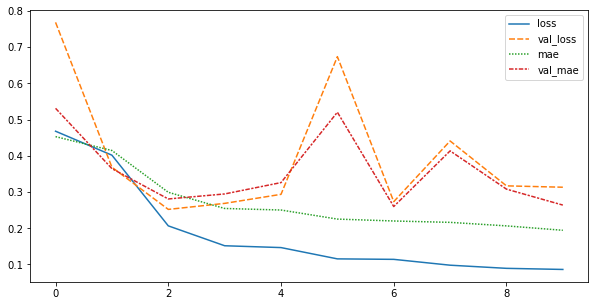

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.lineplot(data=history_data_stand)

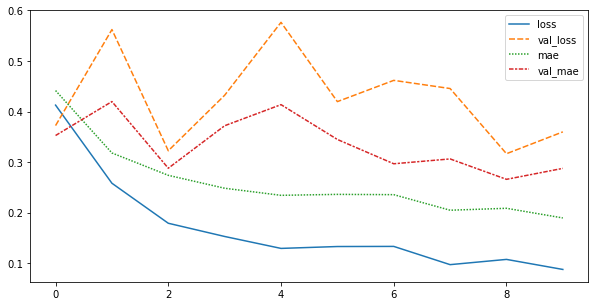

In [75]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=history_data_z_norm)

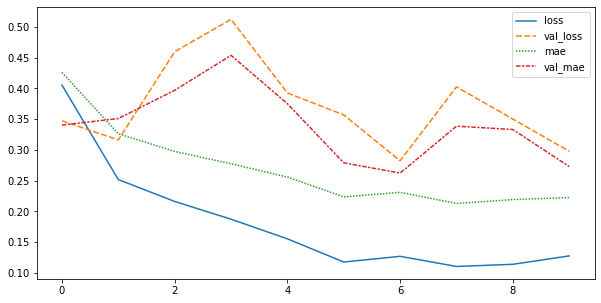

In [76]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=history_data_norm)